In [1]:
import sys

sys.path.append("..")
import polars as pl
import faiss
from src.utils import read_index
from sklearn.model_selection import train_test_split

index, meta = read_index("../index/dinov2_gld_siglip_filtered")
index.hnsw.efSearch = 128

In [75]:
df = pl.read_csv(
    # "../../datasets/google-landmark/index_ref_predicted_siglip_filtered.csv"
    "../../datasets/google-landmark/train_ref_predicted_siglip_filtered.csv"
)
df

landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,supercategory,hierarchical_label,natural_or_human_made,rg_name,rg_admin1,rg_admin2,country_code,country,continent,subregion,id,url,category,confidence
i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
104169,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",56.123889,-3.947778,null,"""castle""","""castle / fort""","""human-made""","""Stirling""","""Scotland""","""Stirling""","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""202cd79556f30760""","""http://upload.wikimedia.org/wi…","""castle_fortress""",0.011797
6888,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.468333,34.144444,null,"""park""","""parks""","""natural""","""Livadiya""","""Crimea""","""""","""UA""","""Ukraine""","""Europe""","""Eastern Europe""","""6f31b874d1a4d489""","""https://upload.wikimedia.org/w…","""garden_park""",0.43833
30319,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",52.226169,21.023186,null,"""embassy""",null,null,"""Srodmiescie""","""Masovian Voivodeship""","""Warszawa""","""PL""","""Poland""","""Europe""","""Eastern Europe""","""4b966789e0572456""","""http://upload.wikimedia.org/wi…","""museum_theater""",0.552456
109163,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",53.4304,14.5597,null,"""Eastern Orthodox church""","""church""","""human-made""","""Szczecin""","""West Pomeranian Voivodeship""","""Szczecin""","""PL""","""Poland""","""Europe""","""Eastern Europe""","""4570e7fc14ebfbba""","""https://upload.wikimedia.org/w…","""church_cathedral""",0.016026
73107,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",38.707778,-77.086111,null,"""estate""",null,null,"""Mount Vernon""","""Virginia""","""Fairfax County""","""US""","""United States""","""Americas""","""Northern America""","""ec1a06b33bc85437""","""https://upload.wikimedia.org/w…","""palace_manor""",0.00502
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
47198,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",-3.723137,-38.52525,null,"""fortress of Brazil""","""castle / fort""","""human-made""","""Fortaleza""","""Ceara""","""Fortaleza""","""BR""","""Brazil""","""Americas""","""South America""","""2cbc16f34f2cd050""","""https://upload.wikimedia.org/w…","""museum_theater""",0.005665
33508,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",50.9292,13.6767,null,"""forest""",null,null,"""Dippoldiswalde""","""Saxony""","""""","""DE""","""Germany""","""Europe""","""Western Europe""","""83bd91e42dc6a2ab""","""https://upload.wikimedia.org/w…","""ruins""",0.001106
42142,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",38.752778,-9.184722,null,"""association football stadium""","""sports venue""","""human-made""","""Pontinha""","""Lisbon""","""Odivelas""","""PT""","""Portugal""","""Europe""","""Southern Europe""","""8877b1c333e1f1ad""","""https://upload.wikimedia.org/w…","""monument_statue""",0.069952


In [ ]:
import polars as pl
import numpy as np


def stratified_split(
    df: pl.DataFrame,
    category_col: str = "category",
    country_col: str = "country",
    test_size: float = 0.1,
    min_group_size: int = 10,
    seed: int = 42,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    rng = np.random.default_rng(seed)

    df = df.with_columns(pl.Series("__rand", rng.random(len(df))))

    df = df.with_columns(
        [
            pl.col("__rand")
            .rank("ordinal")
            .over([category_col, country_col])
            .alias("__rank"),
            pl.len().over([category_col, country_col]).alias("__group_size"),
        ]
    )

    df = df.with_columns(
        (
            (pl.col("__rank") <= (pl.col("__group_size") * test_size).floor())
            & (pl.col("__group_size") >= min_group_size)
        ).alias("__is_test")
    )

    drop_cols = ["__rand", "__rank", "__group_size", "__is_test"]
    train = df.filter(~pl.col("__is_test")).drop(drop_cols)
    test = df.filter(pl.col("__is_test")).drop(drop_cols)

    return train, test

In [ ]:
train_df, test_df = stratified_split(df, test_size=0.1)

# Sanity check
print(
    test_df.group_by(["category", "country"])
    .len()
    .join(
        df.group_by(["category", "country"]).len(),
        on=["category", "country"],
        suffix="_total",
    )
    .with_columns((pl.col("len") / pl.col("len_total")).alias("test_ratio"))
    .select(["category", "country", "test_ratio"])
    .describe()
)

shape: (9, 4)
┌────────────┬───────────┬───────────────┬────────────┐
│ statistic  ┆ category  ┆ country       ┆ test_ratio │
│ ---        ┆ ---       ┆ ---           ┆ ---        │
│ str        ┆ str       ┆ str           ┆ f64        │
╞════════════╪═══════════╪═══════════════╪════════════╡
│ count      ┆ 1662      ┆ 1662          ┆ 1662.0     │
│ null_count ┆ 0         ┆ 0             ┆ 0.0        │
│ mean       ┆ null      ┆ null          ┆ 0.092196   │
│ std        ┆ null      ┆ null          ┆ 0.010944   │
│ min        ┆ arch_gate ┆ Afghanistan   ┆ 0.052632   │
│ 25%        ┆ null      ┆ null          ┆ 0.089744   │
│ 50%        ┆ null      ┆ null          ┆ 0.097087   │
│ 75%        ┆ null      ┆ null          ┆ 0.099567   │
│ max        ┆ tower     ┆ Åland Islands ┆ 0.1        │
└────────────┴───────────┴───────────────┴────────────┘


In [ ]:
train_df.write_csv(
    "../../datasets/google-landmark/train_ref_predicted_siglip_filtered_train.csv"
)
test_df.write_csv(
    "../../datasets/google-landmark/train_ref_predicted_siglip_filtered_test.csv"
)

## CIRCO-like benchmark dataset construction

In [277]:
import sys

sys.path.append("..")
import polars as pl
from src.utils import read_index
import random
from PIL import Image
from tqdm import tqdm
import json

index, meta = read_index("../index/dinov2_gld_siglip_filtered")
index.hnsw.efSearch = 128
meta = meta["metadata"]

In [195]:
index_df = pl.read_csv(
    "../../datasets/google-landmark/index_ref_predicted_siglip_filtered.csv"
)
index_df.head()

row_idx,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,supercategory,hierarchical_label,natural_or_human_made,rg_name,rg_admin1,rg_admin2,country_code,country,continent,subregion,id,category,confidence
i64,i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
0,36227,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",38.892778,-77.023056,null,"""archive building""",null,null,"""Washington, D.C.""","""Washington, D.C.""","""""","""US""","""United States""","""America""","""Northern America""","""2eaf1281b9715e91""","""railway_station""",0.019987
1,39704,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",16.284983,121.091865,null,"""church building""","""church""","""human-made""","""Malasin""","""Cagayan Valley""","""Province of Nueva Vizcaya""","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""d3b1332814fc7b80""","""temple_shrine""",0.01273
2,40249,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.8309,-71.41496,null,"""capitol building""",null,null,"""Providence""","""Rhode Island""","""Providence County""","""US""","""United States""","""America""","""Northern America""","""581544d78bb3feb4""","""railway_station""",0.000355
3,84013,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",40.406714,-3.71162,null,"""city gate""","""gate""","""human-made""","""Madrid""","""Madrid""","""Provincia de Madrid""","""ES""","""Spain""","""Europe""","""Southern Europe""","""72f1048035d11f8e""","""arch_gate""",0.802222
4,41641,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",54.083,13.9162,null,"""pier""","""harbor""","""human-made""","""Ostseebad Zinnowitz""","""Mecklenburg-Vorpommern""","""""","""DE""","""Germany""","""Europe""","""Western Europe""","""ece2023f36ad9863""","""harbor_pier""",0.692005


In [ ]:
# import country_converter as coco
# import pycountry

# cc = coco.CountryConverter()


# def fill_region(code: str):
#     country = pycountry.countries.get(alpha_2=code)
#     return {
#         "country_code": code,
#         "country_name": country.name if country else None,
#         "continent": cc.convert(code, to="continent"),
#         "subregion": cc.convert(code, to="UNregion"),
#     }

# country_codes = index_df.select("country_code").unique().to_numpy().reshape(-1).tolist()
# regions = []
# for code in country_codes:
#     regions.append(fill_region(code))

# region_df = pl.DataFrame(regions)
# region_df.head()

# index_df.with_row_index("row_idx").join(
#     region_df, on="country_code", how="left"
# ).with_columns(
#     [
#         pl.col("continent_right").alias("continent"),
#         pl.col("subregion_right").alias("subregion"),
#     ]
# ).drop(["continent_right", "subregion_right", "country_name"]).write_csv(
#     "../../datasets/google-landmark/index_ref_predicted_siglip_filtered.csv"
# )

In [201]:
index_df.filter(pl.col("confidence") >= 0.5).sort("confidence").group_by(
    ["landmark_id"]
).len().sort("len")

landmark_id,len
i64,u32
7482,1
11284,1
84814,1
86779,1
13770,1
…,…
67663,24
67422,25
95692,25


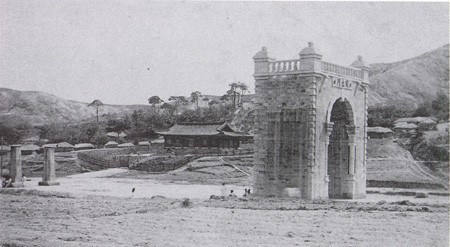

In [ ]:
Image.open("../../datasets/google-landmark/index-img/9540941869f88402.jpg")

In [221]:
def sample_balanced_seeds(df: pl.DataFrame, total_seeds: int, random_seed: int = 42):
    # Step 1 — one representative per unique landmark identity
    landmark_representatives = df.group_by(
        *["category", "continent", "country", "landmark_id"]
    ).map_groups(lambda g: g.sample(n=1, seed=random_seed, with_replacement=False))

    # Step 2 — quota per (category, continent) cell for top-level balance
    n_cells = landmark_representatives.select(["category", "continent"]).unique().height
    continent_quota = max(1, total_seeds // n_cells)
    print(f"continent-level cells: {n_cells:,} | quota per cell: {continent_quota}")

    # Step 3 — within each (category, continent) cell, enforce per-country sub-quota
    def sample_cell_with_country_balance(g: pl.DataFrame) -> pl.DataFrame:
        n_countries = g.select("country").unique().height
        country_quota = max(1, continent_quota // n_countries)
        return (
            g.group_by("country")
            .map_groups(
                lambda cg: cg.sample(
                    n=min(country_quota, len(cg)),
                    seed=random_seed,
                    with_replacement=False,
                )
            )
            .head(continent_quota)
        )  # cap at continent quota in case of rounding overflow

    sampled = landmark_representatives.group_by(*["category", "continent"]).map_groups(
        sample_cell_with_country_balance
    )

    actual = sampled.height
    print(f"Sampled {actual:,} seeds (requested {total_seeds:,})")

    if actual < int(total_seeds * 0.9):
        print(
            f"Delivered only {actual}/{total_seeds} seeds. "
            f"Many cells are sparse — consider reducing total_seeds."
        )

    seed_indices = sampled["row_idx"].to_list()
    rng = random.Random(random_seed)
    rng.shuffle(seed_indices)
    return seed_indices

In [222]:
seed_df = index_df.filter(pl.col("confidence") >= 0.5)
seed_ind = sample_balanced_seeds(seed_df, total_seeds=1000)
seed_df = index_df[seed_ind]

continent-level cells: 76 | quota per cell: 13
Sampled 640 seeds (requested 1,000)
Delivered only 640/1000 seeds. Many cells are sparse — consider reducing total_seeds.


In [283]:
raw_subsets = []

for seed_id in tqdm(seed_ind, desc="generating subset"):
    feat = index.reconstruct(seed_id).reshape(1, -1)
    sims, idxs = index.search(feat, 200 + 1)
    sims = sims[0]
    idxs = idxs[0]

    candidates = []
    for idx, sim in zip(idxs, sims):
        idx = int(idx)
        if idx == seed_id:
            continue
        if sim >= 0.95:
            continue
        if meta[idx]["category"] != meta[seed_id]["category"]:
            continue
        if meta[idx]["country"] == meta[seed_id]["country"]:
            continue
        candidates.append({
            "tgt_img_id": idx,
            "tgt_country": meta[idx]["country"],
            "tgt_continent": meta[idx]["continent"],
            "tgt_subregion": meta[idx]["subregion"]
        })

    subset = {
        "subset_id": f"sub_{seed_id}",
        "ref_img_id": seed_id,
        "ref_country": meta[seed_id]["country"],
        "ref_continent": meta[seed_id]["continent"],
        "ref_subregion": meta[seed_id]["subregion"],
        "ref_category": meta[seed_id]["category"],
        "target_imgs": candidates
    }
    raw_subsets.append(subset)

with open("../../datasets/geocir-triplet/raw_subset.json", "w") as f:
    f.write(json.dumps({"data": raw_subsets}))

generating subset: 100%|██████████| 640/640 [00:00<00:00, 1479.66it/s]


In [326]:
def generate_query_pairs(raw_subsets):
    queries = []

    for subset in raw_subsets:
        ref_id = subset["ref_img_id"]
        ref_country = subset["ref_country"]
        ref_continent = subset["ref_continent"]
        ref_category = subset["ref_category"]
        targets = subset["target_imgs"]

        # country level
        country_buckets = {}
        for t in targets:
            country_buckets.setdefault(t["tgt_country"], []).append(t)

        for c in country_buckets.keys():
            q = {
                "query_id": f"{subset["subset_id"]}_q_{ref_id}_c1_{c}",
                "granularity": "country",
                "ref_img_id": ref_id,
                "ref_country": ref_country,
                "ref_category": ref_category,
                "caption": f"similar landmark located in {c}",
                "target_img_ids": [t["tgt_img_id"] for t in targets if t["tgt_country"] == c]
            }
            queries.append(q)

        # continent level
        continent_buckets = {}
        for t in targets:
            if t["tgt_continent"] != ref_continent:
                continent_buckets.setdefault(t["tgt_continent"], []).append(t)
        
        for c in continent_buckets.keys():
            q = {
                "query_id": f"{subset["subset_id"]}_q_{ref_id}_c2_{c}",
                "granularity": "continent",
                "ref_img_id": ref_id,
                "ref_continent": ref_continent,
                "ref_category": ref_category,
                "caption": f"similar landmark located in {c}",
                "target_img_ids": [t["tgt_img_id"] for t in targets if t["tgt_continent"] == c]
            }
            queries.append(q)

    return queries


queries = generate_query_pairs(raw_subsets)
print(f"Total queries: {len(queries)}")
print(f"  country-level : {sum(1 for q in queries if q['granularity'] == 'country')}")
print(f"  continent-level: {sum(1 for q in queries if q['granularity'] == 'continent')}")

with open("../../datasets/geocir-triplet/test.v1.json", "w") as f:
    f.write(json.dumps({"data": queries}))

Total queries: 16372
  country-level : 14576
  continent-level: 1796
